### Zadania
1. Napisać własną implementację interpolacji wielomianowej stosując wprost wzór na wielomian interpolacyjny  Lagrange'a .  Przetestować swoją implementację na wylosowanych węzłach interpolacji w wybranym przedziale. Narysować wykres wielomianu interpolacyjnego w tym przedziale wraz z wezlami interpolacji. <b>(1 pkt)</b>

1. Zrobic to samo dla metody  Newtona (metoda ilorazów róznicowych).Narysować wykres wielomianu interpolacyjnego otrzymanego metodą Newtona dla tych samych danych, co w poprzednim punkcie. Zadbać o to, żeby ilorazy wyliczać tylko raz dla danego zbioru wezłow interpolacji, według schematu z pakietu Interpolations http://juliamath.github.io/Interpolations.jl/stable/interpolations/ : 
   1. napisać funkcję `NewtonInterpolation`, która wylicza ilorazy różnicowe i zwraca "obiekt interpolacyjny" `newt`
   1. napisać funkcję która wylicza wartość wielomianu dla obiektu `newt` w punkcie x za pomocą  <b>schematu Hornera dla postaci Newtona </b> <b>(2 pkt)</b>

1. Zastosować interpolację wielomianową z pakietu Polynomials do tych samych danych, co w poprzednich punktach. Porównać wszystkie 3 wyniki interpolacji wielomianowej na jednym wykresie. Co zauważamy? Dlaczego? <b>(1 pkt)</b>

1. Porównać metody poprzez pomiar czasu wykonania dla zmiennej ilości węzłow interpolacji. Uwaga: dodatkowo, dla metody Newtona i pakietu Polynomials należy osobno zmierzyć czas wyliczania wielomianu i osobno czas wyliczania wartości w punkcie. Dokonać pomiaru 10 razy i policzyć wartość średnią oraz oszacować błąd pomiaru za pomocą odchylenia standardowego; wyniki przedstawić na wykresach. <b>(2 pkt)</b>

1. Zaimplementować algorytm Neville’a i sprawdzić (dla kilku wybranych punktów), czy daje te same wartości wielomianu co wybrana interpolacja wielomianowa.<b>(1 pkt)</b>

1. Poeksperymentować z  interpolacją funkcjami sklejanymi (minimum dwie różne funkcje sklejane),  narysować wykresy i porównać z wykresami interpolacji wielomianowej. <b>Zademonstrować  efekt Rungego</b> <b>(1 pkt)</b>. 

In [4]:
using Plots, Polynomials, Interpolations

In [5]:
# Zadanie 1
# Interpolacja wielomianowa (Langrange'a)

# Losowanie węzłów interpolacji (xs oraz ys to odgórnie znane wartości wykorzystywane do interpolacji)
xs =  1:1:10
ys = [rand() for x in xs]

10-element Vector{Float64}:
 0.15787441563780347
 0.0841013644891695
 0.10012020163476365
 0.4162802645368524
 0.4561019943219663
 0.04155618306258391
 0.2659453372914462
 0.7236661286755847
 0.5408384467678156
 0.9333256665478971

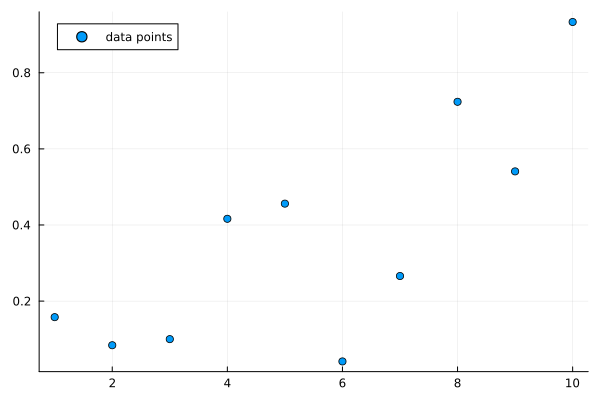

In [6]:
# Szkicowanie węzłów interpolacji
scatter(xs,ys, label="data points")

In [7]:
# Implementacja interpolacji Lagrange'a
function LagrangeBase(x, xs, k)
    result = 1.0
    for i in eachindex(xs)
        if i != k
            result *= (x - xs[i]) / (xs[k] - xs[i])
        end
    end
    return result
end

function LagrangePolynomial(x, xs, ys)
    return sum(ys[k] * LagrangeBase(x, xs, k) for k in eachindex(xs))
end

LagrangePolynomial (generic function with 1 method)

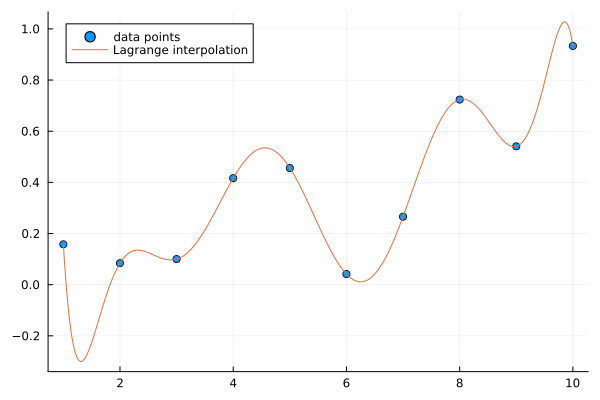

In [8]:
# Wykres interpolacji
xsf=1:0.01:10
ysf = [LagrangePolynomial(x, xs, ys) for x in xsf] 
plot!(xsf, ysf, label="Lagrange interpolation")

In [9]:
# Zadanie 2
# Interpolacja metodą Newtona 
# A. napisać funkcję NewtonInterpolation, która wylicza ilorazy różnicowe i zwraca "obiekt interpolacyjny" newt
function NewtonInterpolation(xs, ys)
    # Tworzymy macierz n×n wypełnioną zerami i wpisujemy do pierwszej kolumny wartości ys
    n = length(xs)
    newt = zeros(n,n)
    
    # 1 kolumna (0-we ilorazy różnicowe)
    for i in 1:n
        newt[i,1] = ys[i]
    end

    # Wypełniamy resztę macierzy (korzystając z zapamiętanych ilorazów)
    for k in 2:n
        for i in 1:(n - k + 1)
            newt[i, k] = (newt[i+1, k-1] - newt[i, k-1]) / (xs[i+k-1] - xs[i])
        end
    end
    
    return newt
end


NewtonInterpolation (generic function with 1 method)

In [10]:
# B. napisać funkcję która wylicza wartość wielomianu dla obiektu newt w punkcie x za pomocą schematu Hornera dla postaci Newtona
function NewtonPolynomial(x, xs, newt)
    n = length(xs)
    result = newt[1, 1]
    product = 1.0

    for k in 2:n
        product *= (x - xs[k-1])
        result += newt[1, k] * product
    end

    return result
end

NewtonPolynomial (generic function with 1 method)

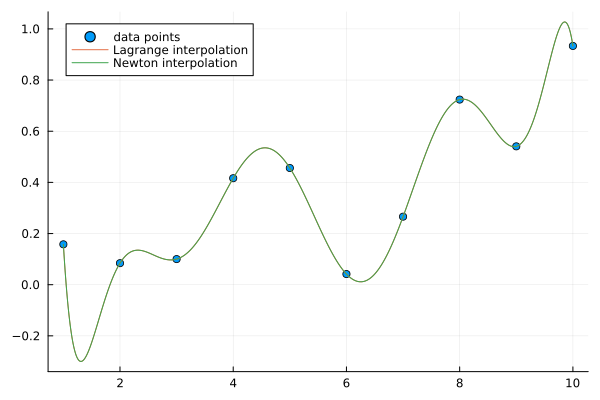

In [11]:
# Wykres interpolacji
xsf=1:0.01:10
newt = NewtonInterpolation(xs, ys)
ysf = [NewtonPolynomial(x, xs, newt) for x in xsf] 
plot!(xsf, ysf, label="Newton interpolation")

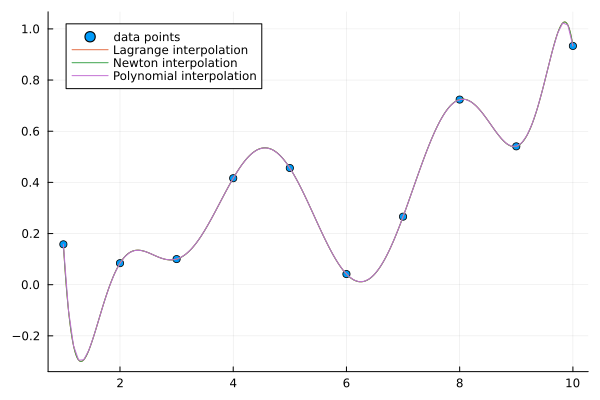

In [12]:
# Zadanie 3 
# Interpolacja wielomianowa z pakietu Polynomials 
# Porównać wszystkie 3 wyniki interpolacji wielomianowej na jednym wykresie. Co zauważamy? Dlaczego?
using Polynomials 
f = fit(xs, ys)
plot!(f,  extrema(xs)..., label="Polynomial interpolation")

In [13]:
# Wszystkie wykresy się nakładają ze względu na jednoznaczność rozwiązania - niezależnie od metody, zawsze uzyskamy ten sam wzór wielomianu.

In [49]:
# Zadanie 4 
# Porównywanie czasu interpolacji.
# Porównać metody poprzez pomiar czasu wykonania dla zmiennej ilości węzłow interpolacji. 
# Uwaga: dodatkowo, dla metody Newtona i pakietu Polynomials należy osobno zmierzyć czas wyliczania wielomianu i osobno czas wyliczania wartości w punkcie. 
# Dokonać pomiaru 10 razy i policzyć wartość średnią oraz oszacować błąd pomiaru za pomocą odchylenia standardowego; wyniki przedstawić na wykresach.
using CSV, Statistics, DataFrames, Plots, LinearAlgebra, Polynomials

results = DataFrame(num = Int[], function_name = String[], time_elapsed = Float64[])

number_of_interpolation_nodes = [10,20,50,100,200]

x = 0.25

# Pomiary czasu 
for n in number_of_interpolation_nodes
    xs = rand(n)
    ys = rand(n)

    time_for_lagrange_result = Float64[]
    time_for_newton_result = Float64[]
    time_for_newton_poly = Float64[]
    time_for_polynomial_result = Float64[]
    time_for_polynomial_poly = Float64[]
    
    for i in 1:10
        t1 = @elapsed LagrangePolynomial(x,xs,ys)
        push!(time_for_lagrange_result, t1)

        t2 = @elapsed newt = NewtonInterpolation(xs,ys)
        t3 = @elapsed NewtonPolynomial(x,xs,newt)
        push!(time_for_newton_poly, t2)
        push!(time_for_newton_result, t3)

        t4 = @elapsed p = fit(xs,ys)
        t5 = @elapsed p(x)
        push!(time_for_polynomial_poly, t4)
        push!(time_for_polynomial_result, t5)
    end

    for t in time_for_lagrange_result
        push!(results, (n, "lagrange_result", t))
    end
    
    for t in time_for_newton_result
        push!(results, (n, "newton_result", t))
    end

    for t in time_for_newton_poly
        push!(results, (n, "newton_poly", t))
    end

    for t in time_for_polynomial_result
        push!(results, (n, "poly_result", t))
    end

    for t in time_for_polynomial_poly
        push!(results, (n, "poly_poly", t))
    end
end

In [50]:
# Grupowanie danych według funkcji i rozmiaru wektora
data_grouped = groupby(results, [:function_name, :num])

# Obliczenie średniej i odchylenia standardowego dla każdej funkcji i num
grouped = combine(data_grouped, :time_elapsed => mean => :mean_time, :time_elapsed => std => :std_time)

# Podział danych na grupy
lagrange_data = filter(row -> row.function_name == "lagrange_result", grouped)
newton_eval_data = filter(row -> row.function_name == "newton_result", grouped)
newton_poly_data = filter(row -> row.function_name == "newton_poly", grouped)
poly_eval_data = filter(row -> row.function_name == "poly_result", grouped)
poly_poly_data = filter(row -> row.function_name == "poly_poly", grouped)

Row,function_name,num,mean_time,std_time
,String,Int64,Float64,Float64
1,poly_poly,10,2.14e-6,4.24138e-6
2,poly_poly,20,1.74e-6,4.59952e-7
3,poly_poly,50,9.17e-6,2.38982e-6
4,poly_poly,100,3.202e-5,4.55724e-6
5,poly_poly,200,0.00011148,2.34721e-5


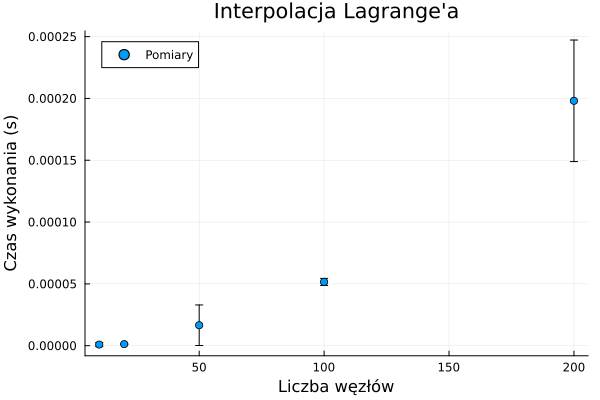

In [51]:
# Wykres 1
plot1 = scatter(lagrange_data.num, lagrange_data.mean_time, yerr=lagrange_data.std_time, seriestype=:scatter, 
    label="Pomiary", xlabel="Liczba węzłów", ylabel="Czas wykonania (s)", title="Interpolacja Lagrange'a", legend=:topleft)

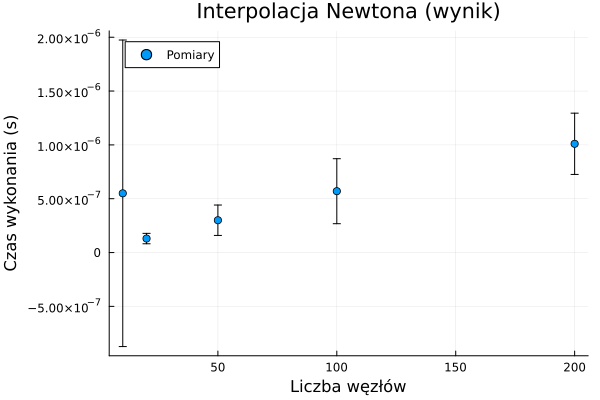

In [52]:
# Wykres 2
plot2 = scatter(newton_eval_data.num, newton_eval_data.mean_time, yerr=newton_eval_data.std_time, seriestype=:scatter, 
    label="Pomiary", xlabel="Liczba węzłów", ylabel="Czas wykonania (s)", title="Interpolacja Newtona (wynik)", legend=:topleft)

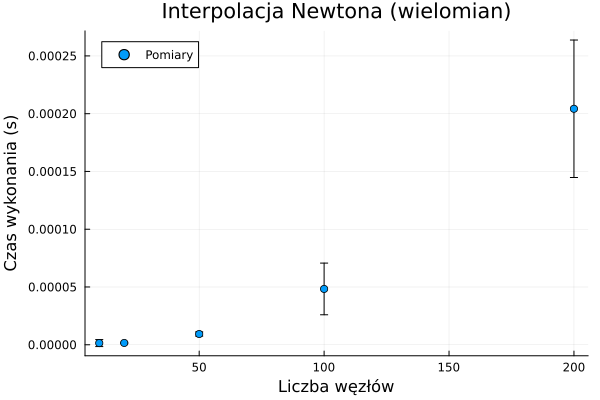

In [53]:
# Wykres 3
plot3 = scatter(newton_poly_data.num, newton_poly_data.mean_time, yerr=newton_poly_data.std_time, seriestype=:scatter, 
    label="Pomiary", xlabel="Liczba węzłów", ylabel="Czas wykonania (s)", title="Interpolacja Newtona (wielomian)", legend=:topleft)

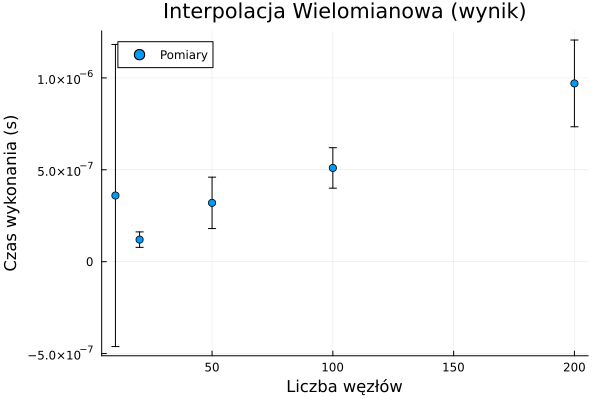

In [54]:
# Wykres 4
plot4 = scatter(poly_eval_data.num, poly_eval_data.mean_time, yerr=poly_eval_data.std_time, seriestype=:scatter, 
    label="Pomiary", xlabel="Liczba węzłów", ylabel="Czas wykonania (s)", title="Interpolacja Wielomianowa (wynik)", legend=:topleft)

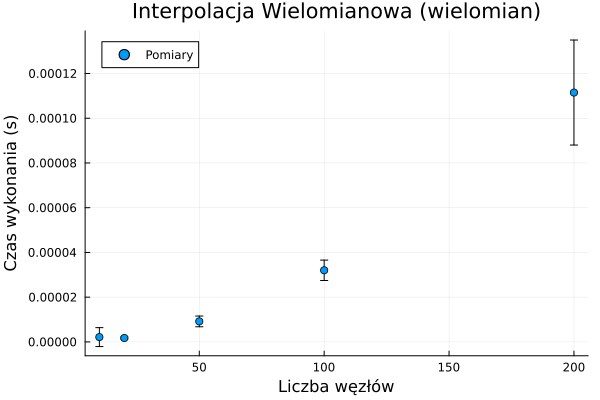

In [55]:
# Wykres 5
plot5 = scatter(poly_poly_data.num, poly_poly_data.mean_time, yerr=poly_poly_data.std_time, seriestype=:scatter, 
    label="Pomiary", xlabel="Liczba węzłów", ylabel="Czas wykonania (s)", title="Interpolacja Wielomianowa (wielomian)", legend=:topleft)

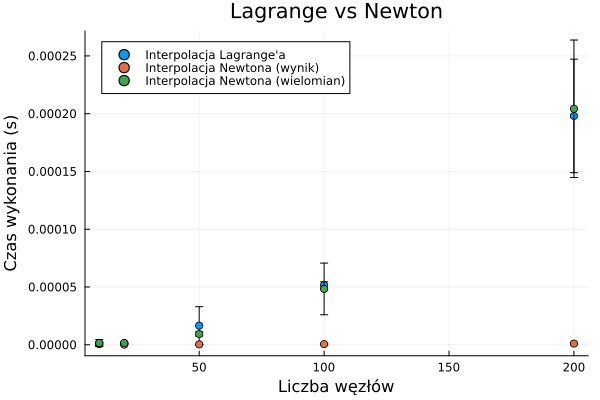

In [56]:
# Lagrange vs Newton

plot(lagrange_data.num, lagrange_data.mean_time, yerr=lagrange_data.std_time, seriestype=:scatter, 
    label="Interpolacja Lagrange'a", xlabel="Liczba węzłów", ylabel="Czas wykonania (s)", title="Lagrange vs Newton", legend=:topleft)

plot!(newton_eval_data.num, newton_eval_data.mean_time, yerror = newton_eval_data.std_time, seriestype = :scatter,
    label = "Interpolacja Newtona (wynik)")

plot!(newton_poly_data.num, newton_poly_data.mean_time, yerror = newton_poly_data.std_time, seriestype = :scatter,
    label = "Interpolacja Newtona (wielomian)")

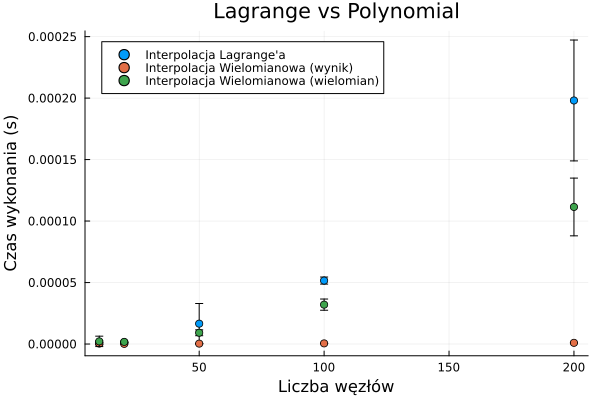

In [57]:
# Lagrange vs Polynomial

plot(lagrange_data.num, lagrange_data.mean_time, yerr=lagrange_data.std_time, seriestype=:scatter, 
    label="Interpolacja Lagrange'a", xlabel="Liczba węzłów", ylabel="Czas wykonania (s)", title="Lagrange vs Polynomial", legend=:topleft)

plot!(poly_eval_data.num, poly_eval_data.mean_time, yerror = poly_eval_data.std_time, seriestype = :scatter,
    label = "Interpolacja Wielomianowa (wynik)")

plot!(poly_poly_data.num, poly_poly_data.mean_time, yerror = poly_poly_data.std_time, seriestype = :scatter,
    label = "Interpolacja Wielomianowa (wielomian)")

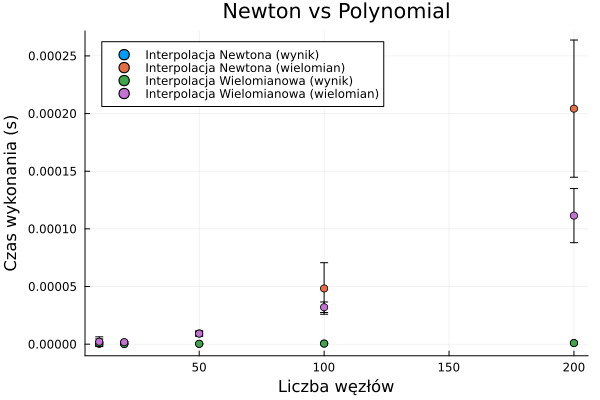

In [58]:
# Polynomial vs Newton

plot(newton_eval_data.num, newton_eval_data.mean_time, yerr=newton_eval_data.std_time, seriestype=:scatter, 
    label="Interpolacja Newtona (wynik)", xlabel="Liczba węzłów", ylabel="Czas wykonania (s)", title="Newton vs Polynomial", legend=:topleft)

plot!(newton_poly_data.num, newton_poly_data.mean_time, yerror = newton_poly_data.std_time, seriestype = :scatter,
    label = "Interpolacja Newtona (wielomian)")

plot!(poly_eval_data.num, poly_eval_data.mean_time, yerror = poly_eval_data.std_time, seriestype = :scatter,
    label = "Interpolacja Wielomianowa (wynik)")

plot!(poly_poly_data.num, poly_poly_data.mean_time, yerror = poly_poly_data.std_time, seriestype = :scatter,
    label = "Interpolacja Wielomianowa (wielomian)")

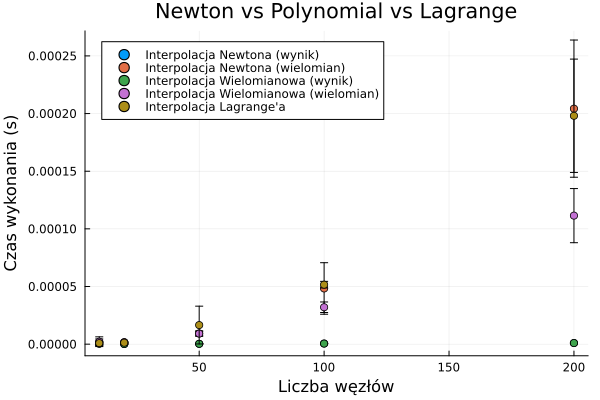

In [59]:
# Final Fight 
plot(newton_eval_data.num, newton_eval_data.mean_time, yerr=newton_eval_data.std_time, seriestype=:scatter, 
    label="Interpolacja Newtona (wynik)", xlabel="Liczba węzłów", ylabel="Czas wykonania (s)", title="Newton vs Polynomial vs Lagrange", legend=:topleft)

plot!(newton_poly_data.num, newton_poly_data.mean_time, yerror = newton_poly_data.std_time, seriestype = :scatter,
    label = "Interpolacja Newtona (wielomian)")

plot!(poly_eval_data.num, poly_eval_data.mean_time, yerror = poly_eval_data.std_time, seriestype = :scatter,
    label = "Interpolacja Wielomianowa (wynik)")

plot!(poly_poly_data.num, poly_poly_data.mean_time, yerror = poly_poly_data.std_time, seriestype = :scatter,
    label = "Interpolacja Wielomianowa (wielomian)")

plot!(lagrange_data.num, lagrange_data.mean_time, yerr=lagrange_data.std_time, seriestype=:scatter, 
    label="Interpolacja Lagrange'a")

In [60]:
# Zadanie 5
# Algorytm Neville'a
# Zaimplementować algorytm Neville’a i sprawdzić (dla kilku wybranych punktów), czy daje te same wartości wielomianu co wybrana interpolacja wielomianowa.
# Istota: budowa tablicy wartosci wielomianów coraz wyższych stopni
function NevilleInterpolation(x, xs, ys)
    n = length(xs)
    P = zeros(n,n)

    for i in 1:n
        P[i,1] = ys[i]
    end

    for m in 2:n  # m to stopień wielomianu + 1
        for i in 1:(n - m + 1)
            j = i + m - 1  # Indeks dla x_{i+m}
            P[i, m] = ((x - xs[j]) * P[i, m-1] + (xs[i] - x) * P[i+1, m-1]) / (xs[i] - xs[j])
        end
    end

    # Wynikiem jest P[1, n], czyli interpolowana wartość w punkcie x
    return P[1, n]
end

NevilleInterpolation (generic function with 1 method)

Porównanie wartości Neville vs Lagrange:
x = 2.0: Neville = 0.9120997723276003, Lagrange = 0.9120997723276001, różnica = 2.220446049250313e-16
x = 2.5: Neville = 0.4817430982037448, Lagrange = 0.48174309820374467, różnica = 1.1102230246251565e-16
x = 3.0: Neville = 0.0855810603776801, Lagrange = 0.0855810603776801, różnica = 0.0
x = 3.5: Neville = 0.16554898819788955, Lagrange = 0.16554898819788955, różnica = 0.0
x = 6.7: Neville = 0.4209745524709938, Lagrange = 0.42097455247099375, różnica = 5.551115123125783e-17
x = 7.89: Neville = 0.5868650764887824, Lagrange = 0.5868650764887824, różnica = 0.0
x = 8.42: Neville = -0.030901234340131638, Lagrange = -0.03090123434013166, różnica = 2.0816681711721685e-17


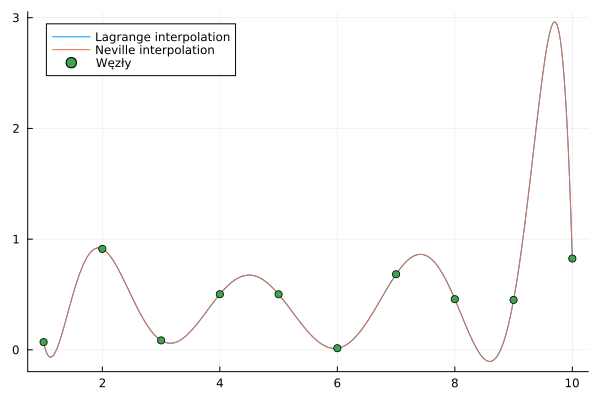

In [61]:
# Porównanie algorytmu Neville'a z interpolacją Lagrange'a

# Punkty do interpolacji
xs =  1:1:10
ys = [rand() for x in xs]
test = [2,2.5,3,3.5,6.7,7.89,8.42]

# Porównanie wartości interpolowanych
println("Porównanie wartości Neville vs Lagrange:")
for x in test
    nev = NevilleInterpolation(x, xs, ys)
    lag = LagrangePolynomial(x, xs, ys)
    println("x = $x: Neville = $nev, Lagrange = $lag, różnica = $(abs(nev - lag))")
end

# Wykres
xsf=1:0.01:10

ys_lagrange = [LagrangePolynomial(x, xs, ys) for x in xsf]
ys_neville = [NevilleInterpolation(x, xs, ys) for x in xsf]

plot(xsf, ys_lagrange, label="Lagrange interpolation")
plot!(xsf, ys_neville, label="Neville interpolation")
scatter!(xs, ys, label="Węzły")

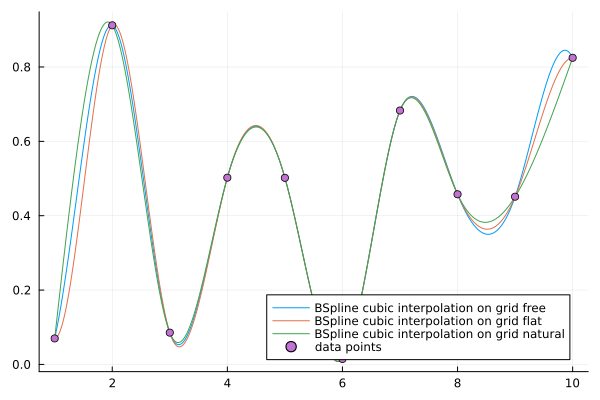

In [62]:
# Zadanie 6
# Interpolacja funkcjami sklejanymi + demonstracja efektu Rungego.
# Poeksperymentować z interpolacją funkcjami sklejanymi (minimum dwie różne funkcje sklejane), narysować wykresy i porównać z wykresami interpolacji wielomianowej.

using Plots, Polynomials, Interpolations

# Przyklad konfiguracji  BSpline-ów (z konspektu)
itp = interpolate(ys, BSpline(Cubic(Free(OnGrid()))))
ysf3=[itp(x) for x in xsf]
plot(xsf,ysf3, label="BSpline cubic interpolation on grid free")
itp = interpolate(ys, BSpline(Cubic(Flat(OnGrid()))))
ysf3=[itp(x) for x in xsf]
plot!(xsf,ysf3, label="BSpline cubic interpolation on grid flat")
itp = interpolate(ys, BSpline(Cubic(Natural(OnGrid()))))
ysf3=[itp(x) for x in xsf]
plot!(xsf,ysf3, label="BSpline cubic interpolation on grid natural")

scatter!(xs,ys, label="data points")

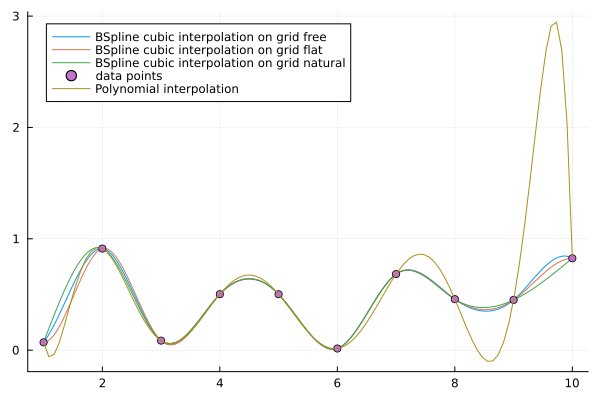

In [63]:
# Porównanie z wykresami interpolacji wielomianowej
using Plots, Polynomials, Interpolations 
f = fit(xs, ys)
plot!(f,  extrema(xs)..., label="Polynomial interpolation")

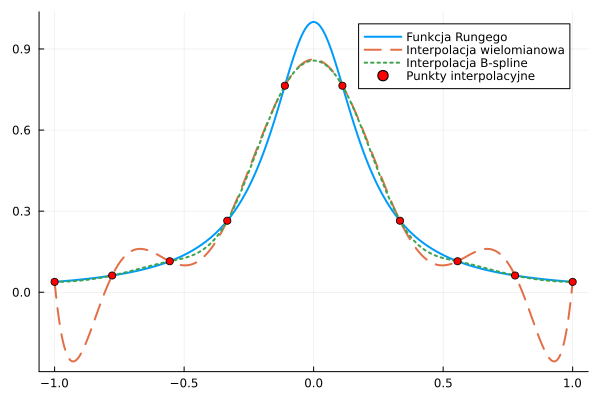

In [64]:
# Demonstracja efektu Rungego 
using Plots, Polynomials, Interpolations

# Funkcja Rungego
runge(x) = 1 / (1 + 25*x^2)

# Przedział i punkty interpolacji
a, b = -1, 1
n = 10
xs = range(a, b, length=n)
ys = runge.(xs)

# Punkty do rysowania wykresu
x_plot = range(a, b, length=500)

# Interpolacja wielomianowa (efekt Rungego)
poly = fit(xs, ys)  # Dopasowanie wielomianu
y_poly = poly.(x_plot)

# Interpolacja B-spline
itp = interpolate(ys, BSpline(Cubic(Flat(OnGrid()))))  
sitp = Interpolations.scale(itp, xs)  # Skalowanie do rzeczywistych wartości x
y_spline = sitp.(x_plot)

# Wykres
plot(x_plot, runge.(x_plot), label="Funkcja Rungego", lw=2)
plot!(x_plot, y_poly, label="Interpolacja wielomianowa", lw=2, ls=:dash)
plot!(x_plot, y_spline, label="Interpolacja B-spline", lw=2, ls=:dot)
scatter!(xs, ys, label="Punkty interpolacyjne", color=:red)